# Эксперимент 01: пайплайн фонемного выравнивания речи

Цель: продемонстрировать работу пайплайна на основе `facebook/wav2vec2-lv-60-espeak-cv-ft` —
от подготовки данных TIMIT до инференса, метрик и REST API.

Весь «боевой» код находится в `src/` — этот ноутбук только импортирует и вызывает его,
не дублируя логику (см. `notebooks/README.md`, `src/README.md`).

In [1]:
import sys
from pathlib import Path

# Добавляем корень проекта в sys.path, чтобы работали импорты `from src...`
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config, resolve_path
from src.env_setup import apply_environment
from src.logging_utils import setup_logger

logger = setup_logger()
cfg = load_config()
apply_environment(cfg, logger=logger)
cfg

2026-06-21 11:44:00 [INFO] voice_model: Зеркало Hugging Face успешно настроено!
2026-06-21 11:44:00 [INFO] voice_model: TORCHAUDIO_BACKEND -> soundfile
2026-06-21 11:44:00 [INFO] voice_model: Путь к espeak настроен!


{'paths': {'dataset_root': 'data/raw/timit',
  'input_dir': 'data/processed/input_audio',
  'audio_dir': 'data/processed/input_audio/audio',
  'annotations_dir': 'data/processed/input_audio/annotations',
  'output_dir': 'data/processed/output_phonemes',
  'artifacts_dir': 'artifacts'},
 'model': {'model_id': 'facebook/wav2vec2-lv-60-espeak-cv-ft',
  'frame_duration': 0.02,
  'top_db': 35},
 'audio': {'valid_audio_extensions': ['.wav', '.flac', '.ogg', '.mp3'],
  'valid_annotation_extensions': ['.json', '.csv', '.txt'],
  'sample_rate': 16000},
 'processing': {'max_files': 20, 'tolerance_ms': [10, 20, 50]},
 'service': {'host': '0.0.0.0', 'port': 8000},
 'env': {'hf_endpoint': 'https://hf-mirror.com',
  'torchaudio_backend': 'soundfile',
  'espeak_path': 'C:/Program Files/eSpeak NG'}}

## 1. Подготовка данных (TIMIT)

Этот блок скачивает датасет TIMIT с Kaggle и конвертирует его в единый формат
`audio/*.wav` + `annotations/*.json`. Требует заполненного `configs/.env`
(см. `configs/README.md`). По умолчанию выключен (`RUN_DOWNLOAD = False`),
чтобы ноутбук можно было запускать без Kaggle credentials.

In [2]:
RUN_DOWNLOAD = True  # поставь True, когда норм настроены configs/.env

# Количество файлов для EDA и обработки.
# 200–500 обеспечивают покрытие всех 8 диалектов TIMIT при случайной выборке.
EDA_SAMPLE_SIZE = 300  # можно изменить в диапазоне 200–500

if RUN_DOWNLOAD:
    from src.data.download_timit import download_and_extract_timit, load_kaggle_credentials
    from src.data.build_dataset import build_dataset

    load_kaggle_credentials(env_path=str(resolve_path('configs/.env')), logger=logger)
    extract_root = download_and_extract_timit(resolve_path(cfg['paths']['dataset_root']), logger=logger)
    stats = build_dataset(
        extract_root,
        resolve_path(cfg['paths']['audio_dir']),
        resolve_path(cfg['paths']['annotations_dir']),
        max_files=EDA_SAMPLE_SIZE,   # случайная выборка задаётся внутри build_dataset
        random_sample=True,           # перемешать перед нарезкой → репрезентативность диалектов
        random_seed=42,
        logger=logger,
    )
    print(stats)
else:
    EDA_SAMPLE_SIZE = 300
    print('Пропускаем скачивание — RUN_DOWNLOAD=False')


2026-06-21 11:44:00 [INFO] voice_model: Конфиг загружен из E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\configs\.env
2026-06-21 11:44:00 [INFO] voice_model: Kaggle credentials загружены из окружения.
2026-06-21 11:44:01 [INFO] voice_model: kaggle уже установлен
2026-06-21 11:44:01 [INFO] voice_model: Архив уже существует: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\data\raw\timit\timit.zip
2026-06-21 11:44:01 [INFO] voice_model: Уже распаковано: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\data\raw\timit\extracted
2026-06-21 11:44:05 [INFO] voice_model: Права на файлы исправлены
2026-06-21 11:44:05 [INFO] voice_model: Найдено WAV файлов: 4684
2026-06-21 11:44:05 [INFO] voice_model: Случайная выборка: seed=42, берём первые 300 из 4684 (после перемешивания)
2026-06-21 11:44:05 [WARNING] voice_model: Нет .PHN для SI1823.WAV.wav - пропуск
2026-06-21 11:44:12 [WARNING] voice_model: Нет .PHN для SI1127.WAV.wav - пропуск
2026-06-21 11:44:

{'processed': 140, 'skipped': 160}


## 2. Разведочный анализ: визуализация аудио

Случайные образцы из `data/processed/input_audio/audio`: осциллограмма, спектр (БПФ),
мел-спектрограмма.

Найдено аудиофайлов: 150


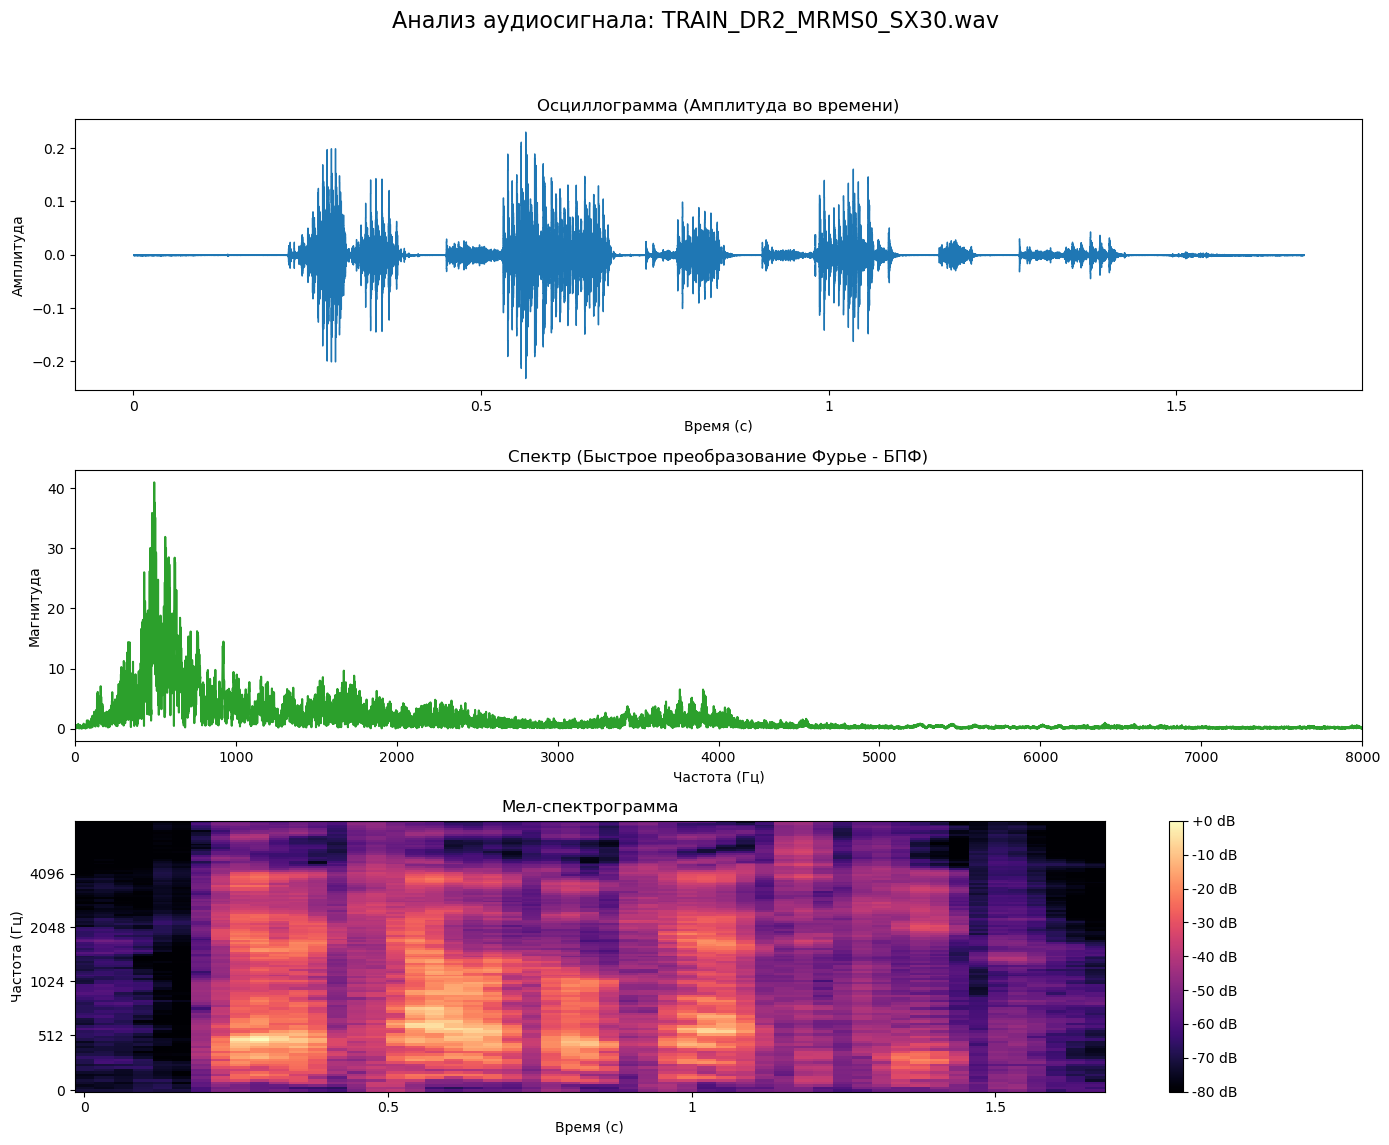

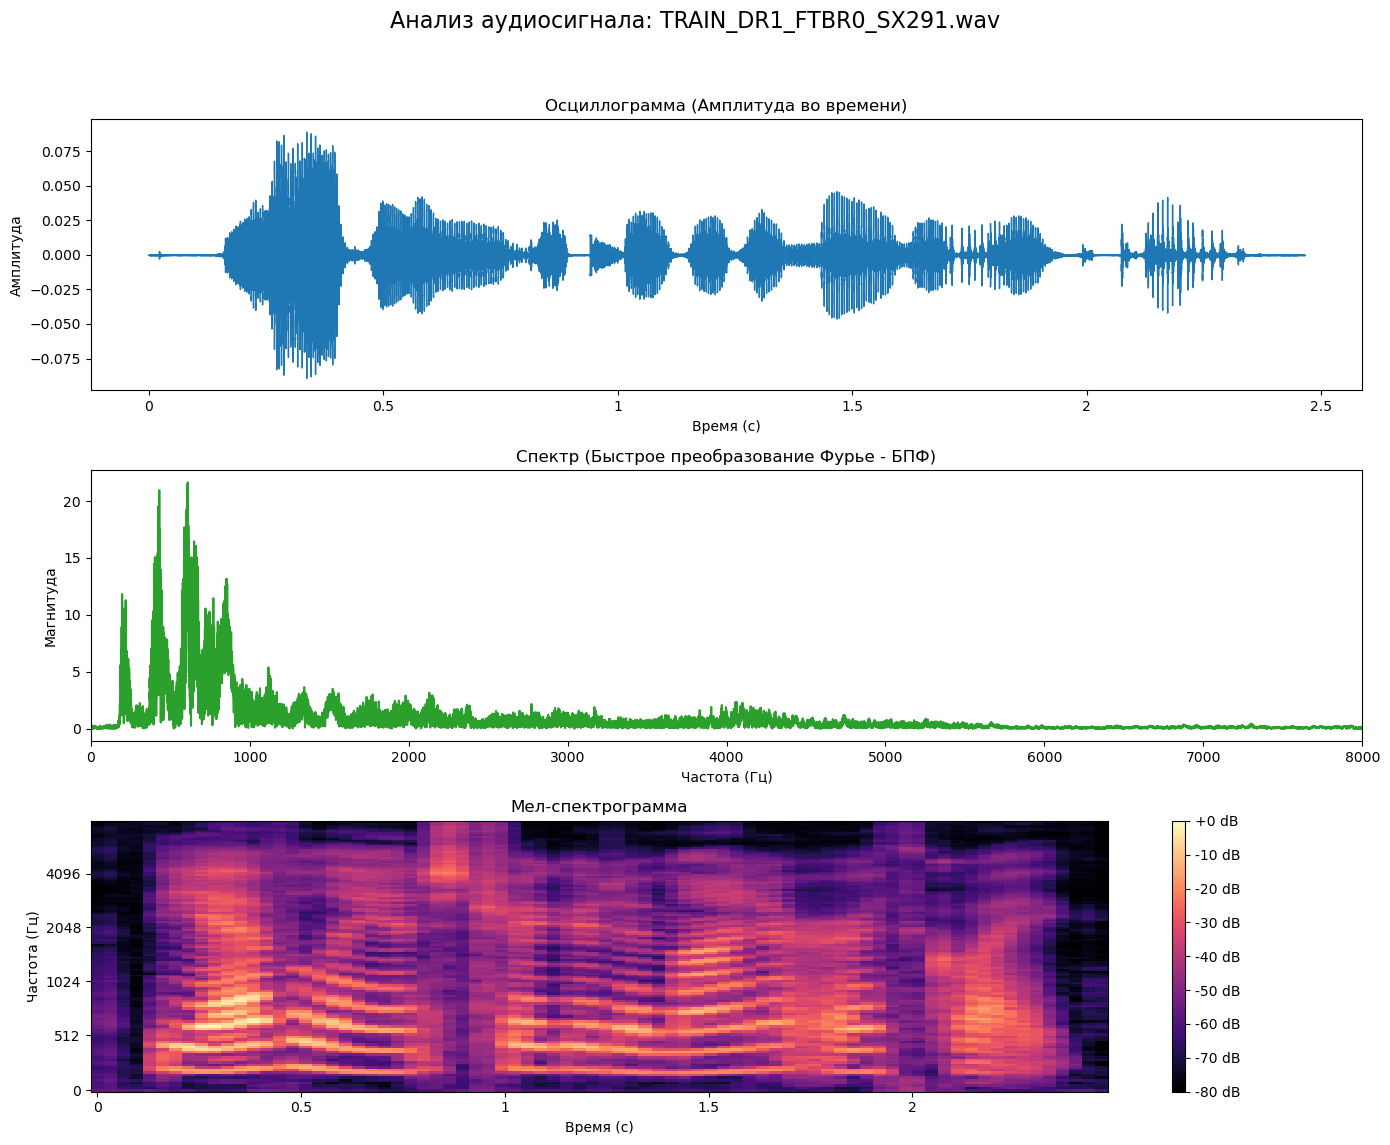

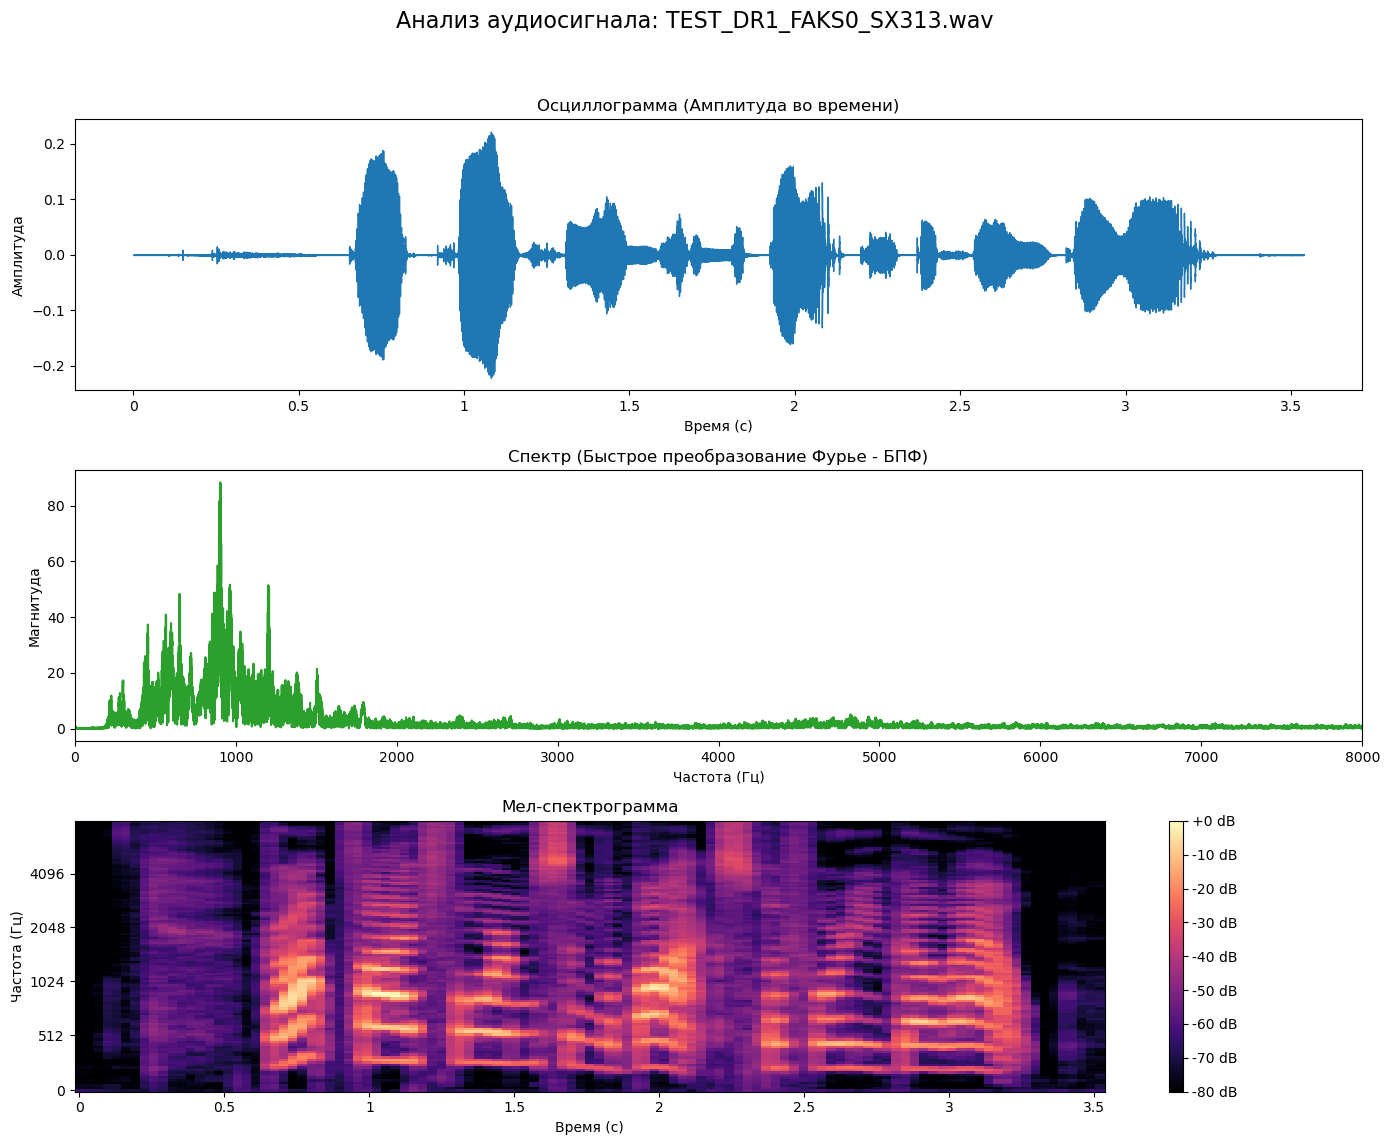

In [3]:
from src.data.audio_utils import list_audio_files
from src.visualize import visualize_samples

audio_dir = resolve_path(cfg['paths']['audio_dir'])
audio_files = list_audio_files(audio_dir, cfg['audio']['valid_audio_extensions'])
print(f'Найдено аудиофайлов: {len(audio_files)}')

visualize_samples(audio_files, str(audio_dir), num_samples=3)

## 2.1 EDA: распределения по датасету

Анализ всего набора файлов TIMIT: длительности, количество фонем на файл,
частоты встречаемости фонем, распределение по диалектам и спикерам.
Выполняется через модуль `src.eda`.

In [4]:
from src.eda import (
    compute_dataset_stats,
    plot_duration_distribution,
    plot_phoneme_frequency,
    plot_dialect_distribution,
    print_eda_summary,
)
import json
from pathlib import Path

audio_dir = resolve_path(cfg['paths']['audio_dir'])
annotations_dir = resolve_path(cfg['paths']['annotations_dir'])
artifacts_dir = resolve_path(cfg['paths']['artifacts_dir'])
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Собираем статистику по всем файлам датасета
stats = compute_dataset_stats(audio_dir, annotations_dir, logger=logger)
print(f"Всего файлов в датасете: {stats['total_files']}")
print(f"Файлов с аннотациями: {stats['files_with_annotations']}")
print(f"Средняя длительность: {stats['mean_duration_sec']:.2f} с")
print(f"Всего уникальных фонем: {stats['unique_phonemes']}")


2026-06-21 11:44:32 [INFO] voice_model: EDA: найдено аудиофайлов: 150
2026-06-21 11:44:33 [INFO] voice_model: EDA: средняя длительность=3.15с, уникальных фонем=60, диалектов=8


Всего файлов в датасете: 150
Файлов с аннотациями: 150
Средняя длительность: 3.15 с
Всего уникальных фонем: 60


In [5]:
# График 1: Распределение длительностей аудио
plot_duration_distribution(stats, save_path=artifacts_dir / 'eda_duration_dist.png')


График сохранён: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\artifacts\eda_duration_dist.png


In [6]:
# График 2: Топ-20 самых частых фонем
plot_phoneme_frequency(stats, top_n=20, save_path=artifacts_dir / 'eda_phoneme_freq.png')


График сохранён: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\artifacts\eda_phoneme_freq.png


In [7]:
# График 3: Распределение по диалектам и количество фонем на файл
plot_dialect_distribution(stats, save_path=artifacts_dir / 'eda_dialect_dist.png')


График сохранён: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\artifacts\eda_dialect_dist.png


In [8]:
# Текстовые выводы по EDA
print_eda_summary(stats)


ВЫВОДЫ ПО EDA ДАТАСЕТА TIMIT

1. Размер датасета: 150 аудиофайлов,
   из них 150 имеют аннотации фонем.

2. Длительность записей: большинство файлов (79%) короче 4 с. Средняя длительность — 3.15 с, медиана — 3.10 с.

3. Фонемный состав: всего 60 уникальных фонем (5950 вхождений). Самые частые: ix, h#, n. Самые редкие: zh, em, ax-h.

4. Диалекты: 8 групп. Наибольшее представление — 'DR1' (31 файлов).

5. Количество фонем на файл: в среднем 39.7 (мин. 12, макс. 71).


## 2.2 EDA: метрики по всему датасету

Запускаем пайплайн по всем файлам и строим сводные графики метрик качества:
гистограмма PER, boxplot ошибок границ, таблица топ-5 худших файлов по PER.
Если пайплайн уже запускался, подгружаем готовый `metrics_summary.json`.

In [9]:
from src.eda import (
    plot_per_histogram,
    plot_boundary_errors_boxplot,
    print_worst_files_table,
)
from src.models.inference import extract_and_save_phonemes
from src.models.metrics import compute_metrics, summarize_metric_rows
from src.models.model_loader import load_model
from src.features.annotation_loader import load_reference_annotation
import json as _json

output_dir    = resolve_path(cfg['paths']['output_dir'])
artifacts_dir = resolve_path(cfg['paths']['artifacts_dir'])
annotations_dir = resolve_path(cfg['paths']['annotations_dir'])
artifacts_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

# audio_files уже определён выше (ячейка 2.1) — это все файлы из audio_dir
# После build_dataset с EDA_SAMPLE_SIZE=300 там лежит 200–500 файлов.
print(f'Файлов в audio_dir для прогона метрик: {len(audio_files)}')

# ── Прогон пайплайна ──────────────────────────────────────────────────────
# Если metrics_summary.json уже существует и содержит нужное количество файлов,
# пересчёт пропускается. Поставь RUN_FULL_PIPELINE=True чтобы пересчитать.
RUN_FULL_PIPELINE = False

metrics_json = output_dir / 'metrics_summary.json'
per_file_rows = []

if not RUN_FULL_PIPELINE and metrics_json.exists():
    raw = _json.loads(metrics_json.read_text(encoding='utf-8'))
    # Файл может быть list[dict] (build_metrics_table) или {per_file:[...]} (run_pipeline)
    if isinstance(raw, list):
        per_file_rows = [r for r in raw if r.get('file_id') != 'AVERAGE']
    else:
        per_file_rows = raw.get('per_file', [])

# Если строк меньше половины audio_files — запускаем полный прогон
if len(per_file_rows) < len(audio_files) // 2:
    print(f'Метрик в кэше: {len(per_file_rows)}, файлов: {len(audio_files)} — запускаем прогон...')

    frame_duration  = cfg['model']['frame_duration']
    top_db          = cfg['model']['top_db']
    tolerance_ms    = tuple(cfg['processing']['tolerance_ms'])
    valid_ann_ext   = cfg['audio']['valid_annotation_extensions']
    valid_audio_ext = cfg['audio']['valid_audio_extensions']

    # Загружаем модель (если ещё не загружена в ячейке 3)
    if 'processor' not in dir() or processor is None:
        processor, model, pad_token_id = load_model(cfg['model']['model_id'], logger=logger)

    per_file_rows = []
    for filepath in audio_files:
        rel   = __import__('os').path.relpath(filepath, str(audio_dir))
        bname = __import__('os').path.splitext(rel)[0].replace(__import__('os').sep, '__')
        out_sub = str(output_dir / bname)
        try:
            meta = extract_and_save_phonemes(
                filepath, out_sub, model, processor, pad_token_id,
                audio_dir=str(audio_dir),
                annotations_dir=str(annotations_dir),
                valid_annotation_extensions=valid_ann_ext,
                frame_duration=frame_duration,
                top_db=top_db,
            )
            pred_segs = meta['prediction']['segments']
            ref_segs  = meta['reference']['segments']
            m = compute_metrics(pred_segs, ref_segs, tolerance_ms=tolerance_ms)
            per_file_rows.append({'source_file': meta['source_file'], **m})
        except Exception as _e:
            logger.error(f'Ошибка {rel}: {_e}')

    # Сохраняем в формате {per_file: [...], summary: {...}}
    summary = summarize_metric_rows(per_file_rows)
    metrics_json.write_text(
        _json.dumps({'per_file': per_file_rows, 'summary': summary},
                    ensure_ascii=False, indent=2),
        encoding='utf-8'
    )
    print(f'Прогон завершён. Обработано файлов: {len(per_file_rows)}')
else:
    print(f'Загружено из кэша: {len(per_file_rows)} файлов')

print(f'Итого строк с метриками: {len(per_file_rows)}')


2026-06-21 11:44:49 [INFO] numexpr.utils: NumExpr defaulting to 12 threads.


Файлов в audio_dir для прогона метрик: 150
Загружено из кэша: 150 файлов
Итого строк с метриками: 150


In [10]:
# График 4: Гистограмма PER по файлам
plot_per_histogram(per_file_rows, save_path=artifacts_dir / 'eda_per_histogram.png')


График сохранён: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\artifacts\eda_per_histogram.png


In [11]:
# График 5: Boxplot ошибок границ
plot_boundary_errors_boxplot(per_file_rows, save_path=artifacts_dir / 'eda_boundary_boxplot.png')


График сохранён: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\artifacts\eda_boundary_boxplot.png


In [12]:
# Таблица: топ-5 худших файлов по PER
print_worst_files_table(per_file_rows, top_n=5)



Топ-5 худших файлов по PER:
───────────────────────────────────────────────────────────────────────────────────────
Файл                                          PER       F1   Фонем (pred)   Фонем (ref)
───────────────────────────────────────────────────────────────────────────────────────
TEST_DR1_MRJO0_SX194.wav                   0.8571   0.1579             17            21
TRAIN_DR7_FREH0_SI685.wav                  0.8485   0.1935             29            33
TRAIN_DR2_FMKF0_SX276.wav                  0.8438   0.1724             26            32
TEST_DR2_MTAS1_SI1473.wav                  0.8421   0.1765             15            19
TEST_DR2_MCEM0_SX228.wav                   0.8333   0.2174             22            24
───────────────────────────────────────────────────────────────────────────────────────


## 3. Загрузка модели

`facebook/wav2vec2-lv-60-espeak-cv-ft` — модель фонемного распознавания (CTC).

In [13]:
from src.models.model_loader import load_model

processor, model, pad_token_id = load_model(cfg['model']['model_id'], logger=logger)

2026-06-21 11:44:51 [INFO] voice_model: Загрузка модели (это может занять пару минут при первом запуске)...
2026-06-21 11:44:52 [INFO] httpx: HTTP Request: GET https://hf-mirror.com/api/models/facebook/wav2vec2-lv-60-espeak-cv-ft/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 308 Permanent Redirect"
2026-06-21 11:44:52 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/facebook/wav2vec2-lv-60-espeak-cv-ft/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-21 11:44:52 [INFO] httpx: HTTP Request: HEAD https://hf-mirror.com/facebook/wav2vec2-lv-60-espeak-cv-ft/resolve/main/processor_config.json "HTTP/1.1 308 Permanent Redirect"
2026-06-21 11:44:53 [INFO] httpx: HTTP Request: HEAD https://hf-mirror.com/facebook/wav2vec2-lv-60-espeak-cv-ft/resolve/main/chat_template.json "HTTP/1.1 308 Permanent Redirect"
2026-06-21 11:44:53 [INFO] httpx: HTTP Request: HEAD https://hf-mirror.com/facebook/wav2vec2-lv-60-

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

2026-06-21 11:44:58 [INFO] voice_model: Модель успешно загружена!


## 4. Прогон пайплайна на одном файле (демо)

Использует `src.models.inference.extract_and_save_phonemes` — извлекает фонемы,
корректирует границы и сравнивает с эталонной аннотацией (если найдена).

In [14]:
from src.models.inference import extract_and_save_phonemes
from src.models.metrics import compute_metrics

if audio_files:
    sample_file = audio_files[0]
    output_subfolder = resolve_path(cfg['paths']['output_dir']) / 'demo_sample'

    metadata = extract_and_save_phonemes(
        sample_file,
        str(output_subfolder),
        model,
        processor,
        pad_token_id,
        audio_dir=str(audio_dir),
        annotations_dir=str(resolve_path(cfg['paths']['annotations_dir'])),
        valid_annotation_extensions=cfg['audio']['valid_annotation_extensions'],
        frame_duration=cfg['model']['frame_duration'],
        top_db=cfg['model']['top_db'],
    )

    metrics = compute_metrics(
        metadata['prediction']['segments'],
        metadata['reference']['segments'],
        tolerance_ms=tuple(cfg['processing']['tolerance_ms']),
    )
    print(f"Извлечено фонем: {metadata['prediction']['count']}")
    print(f"PER: {metrics.get('per')}, F1: {metrics.get('phoneme_f1')}")
else:
    print('Нет аудиофайлов для демонстрации — сначала выполните подготовку данных (шаг 1).')

Извлечено фонем: 32
PER: 0.8048780487804879, F1: 0.21917808219178084


## 5. Полный batch-пайплайн по всем файлам

Эквивалент команды `python -m src.run_pipeline`: обрабатывает все файлы в `audio_dir`,
сохраняет `metadata.json`, сводные метрики `metrics_summary.json` и таблицу
`metrics_comparison.csv` в `output_dir`.

In [15]:
from src import run_pipeline

# run_pipeline.main() сам загружает конфиг и модель — для демонстрации в ноутбуке
# можно вызвать его напрямую:
# run_pipeline.main()
print('Чтобы запустить полный пайплайн, выполните: run_pipeline.main()')

Чтобы запустить полный пайплайн, выполните: run_pipeline.main()


## 6. REST API сервис

Поднимает `/health` и `/predict` в фоновом потоке, не блокируя ноутбук.

In [16]:
RUN_SERVICE = True  # поставьте True, чтобы поднять сервис прямо из ноутбука

if RUN_SERVICE:
    from src.service.api import run_in_background
    run_in_background()
else:
    print('Сервис не запущен. Запустить из терминала: python -m src.service.api')

2026-06-21 11:45:06 [INFO] voice_model.service: Зеркало Hugging Face успешно настроено!
2026-06-21 11:45:06 [INFO] voice_model.service: TORCHAUDIO_BACKEND -> soundfile
2026-06-21 11:45:06 [INFO] voice_model.service: Путь к espeak настроен!
2026-06-21 11:45:06 [INFO] voice_model.service: Загрузка модели (это может занять пару минут при первом запуске)...
2026-06-21 11:45:07 [INFO] httpx: HTTP Request: GET https://hf-mirror.com/api/models/facebook/wav2vec2-lv-60-espeak-cv-ft/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 308 Permanent Redirect"
2026-06-21 11:45:07 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/facebook/wav2vec2-lv-60-espeak-cv-ft/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-21 11:45:07 [INFO] httpx: HTTP Request: HEAD https://hf-mirror.com/facebook/wav2vec2-lv-60-espeak-cv-ft/resolve/main/processor_config.json "HTTP/1.1 308 Permanent Redirect"
2026-06-21 11:45:07 [INFO] ht

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

2026-06-21 11:45:12 [INFO] voice_model.service: Модель успешно загружена!
2026-06-21 11:45:12 [INFO] voice_model.service: Сервис запущен: http://localhost:8000
2026-06-21 11:45:12 [INFO] voice_model.service: Swagger UI:     http://localhost:8000/docs
ERROR:    [Errno 10048] error while attempting to bind on address ('0.0.0.0', 8000): [winerror 10048] обычно разрешается только одно использование адреса сокета (протокол/сетевой адрес/порт)


## 7. Сравнение: Baseline vs Improved (критерий 4)

**Вариант B**: одна модель (`facebook/wav2vec2-lv-60-espeak-cv-ft`), два режима обработки:

| Вариант | Описание |
|---|---|
| **Baseline** | Сырые CTC-предсказания без постобработки |
| **Improved** | CTC + акустическая коррекция границ (`librosa.effects.split/trim`) |

Единственное отличие — наша постобработка в `correct_segment_boundaries()`.
Оба варианта вычисляются за **один проход** через модель (экономия памяти и времени).

In [17]:
from src.compare_models import (
    run_both_variants,
    build_comparison_table,
    plot_comparison,
    plot_boundary_accuracy_by_dialect,
)

audio_dir  = resolve_path(cfg['paths']['audio_dir'])
output_dir = resolve_path(cfg['paths']['output_dir'])
artifacts_dir = resolve_path(cfg['paths']['artifacts_dir'])

audio_files = list_audio_files(audio_dir, cfg['audio']['valid_audio_extensions'])
print(f'Аудиофайлов для сравнения: {len(audio_files)}')


Аудиофайлов для сравнения: 150


In [18]:
# Прогон обоих вариантов (один проход модели на каждый файл)
RUN_COMPARISON = True  # поставь True для первого запуска
comparison_json = output_dir / 'model_comparison.json'

if RUN_COMPARISON or not comparison_json.exists():
    baseline_rows, improved_rows = run_both_variants(
        audio_files, output_dir, cfg, logger
    )
else:
    # Загружаем уже посчитанные результаты
    import pandas as pd
    print('Загружаем готовые результаты из', comparison_json)
    cmp_df = pd.read_json(comparison_json)
    print(cmp_df.to_string())


2026-06-21 11:45:12 [INFO] voice_model: Модель: facebook/wav2vec2-lv-60-espeak-cv-ft
2026-06-21 11:45:12 [INFO] voice_model:   [baseline] Wav2Vec2-LV60 (CTC без постобработки) — сырые границы фонем напрямую из argmax CTC-логитов
2026-06-21 11:45:12 [INFO] voice_model:   [improved] Wav2Vec2-LV60 + акустическая коррекция границ — librosa.effects.split/trim уточняет начало/конец каждого сегмента
2026-06-21 11:45:12 [INFO] voice_model: Файлов: 150
2026-06-21 11:45:12 [INFO] voice_model: Загрузка модели (это может занять пару минут при первом запуске)...
2026-06-21 11:45:12 [INFO] httpx: HTTP Request: GET https://hf-mirror.com/api/models/facebook/wav2vec2-lv-60-espeak-cv-ft/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 308 Permanent Redirect"
2026-06-21 11:45:12 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/facebook/wav2vec2-lv-60-espeak-cv-ft/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-21

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

2026-06-21 11:45:17 [INFO] voice_model: Модель успешно загружена!
2026-06-21 11:45:17 [INFO] voice_model:   Обработка: TEST_DR1_FAKS0_SA1.wav
2026-06-21 11:45:18 [INFO] voice_model:     baseline PER=0.8049  improved PER=0.8049  dialect=DR1
2026-06-21 11:45:18 [INFO] voice_model:   Обработка: TEST_DR1_FAKS0_SA2.wav
2026-06-21 11:45:19 [INFO] voice_model:     baseline PER=0.7353  improved PER=0.7353  dialect=DR1
2026-06-21 11:45:19 [INFO] voice_model:   Обработка: TEST_DR1_FAKS0_SI1573.wav
2026-06-21 11:45:20 [INFO] voice_model:     baseline PER=0.7000  improved PER=0.7000  dialect=DR1
2026-06-21 11:45:20 [INFO] voice_model:   Обработка: TEST_DR1_FAKS0_SI2203.wav
2026-06-21 11:45:21 [INFO] voice_model:     baseline PER=0.5938  improved PER=0.5938  dialect=DR1
2026-06-21 11:45:21 [INFO] voice_model:   Обработка: TEST_DR1_FAKS0_SI943.wav
2026-06-21 11:45:22 [INFO] voice_model:     baseline PER=0.6410  improved PER=0.6410  dialect=DR1
2026-06-21 11:45:22 [INFO] voice_model:   Обработка: TES

In [19]:
# Таблица сравнения + графики
try:
    _ = baseline_rows
    has_rows = bool(baseline_rows)
except NameError:
    has_rows = False

if has_rows:
    comparison_df = build_comparison_table(baseline_rows, improved_rows, output_dir, logger)

    # График 1: PER / Boundary Exact Accuracy @20ms & @50ms / IoU
    plot_comparison(comparison_df, output_dir, logger)

    # График 2: Boundary Exact Accuracy @20ms и @50ms по диалектам TIMIT
    plot_boundary_accuracy_by_dialect(baseline_rows, improved_rows, output_dir, logger)

    # Копируем графики в artifacts/
    import shutil
    for png in ['model_comparison_plot.png', 'boundary_accuracy_by_dialect.png']:
        src_path = output_dir / png
        if src_path.exists():
            shutil.copy(src_path, artifacts_dir / png)
    print('Артефакты сохранены в', artifacts_dir)


2026-06-21 11:47:25 [INFO] voice_model: Таблица сохранена: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\data\processed\output_phonemes\model_comparison.csv



ИТОГОВОЕ СРАВНЕНИЕ (Baseline vs Improved)
                             files_processed     per  phoneme_f1  boundary_start_mae  boundary_end_mae  segment_iou_mean  sequence_exact_match boundary_start_accuracy_20ms boundary_end_accuracy_20ms  boundary_exact_accuracy_20ms  boundary_exact_accuracy_50ms
model                                                                                                                                                                                                                                                             
baseline                               150.0  0.6987      0.3448              0.0234            0.0268            0.3267                   0.0                         None                       None                        0.2847                        0.7601
improved                               150.0  0.6987      0.3448              0.0234            0.0258            0.4671                   0.0                         None         

2026-06-21 11:47:26 [INFO] voice_model: График сравнения: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\data\processed\output_phonemes\model_comparison_plot.png


График: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\data\processed\output_phonemes\model_comparison_plot.png


2026-06-21 11:47:27 [INFO] voice_model: График по диалектам: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\data\processed\output_phonemes\boundary_accuracy_by_dialect.png


График: E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\data\processed\output_phonemes\boundary_accuracy_by_dialect.png
Артефакты сохранены в E:\Visual Studion WORKD\SystemTrayOpt2\aie-KuzmichevNY\project\artifacts


### Интерпретация результатов сравнения

По итогам прогона на 150 файлах (`files_processed = 150`) получены следующие значения:

| Метрика | baseline | improved | Δ (improved − baseline) |
|---|---|---|---|
| **PER** | 0.6987 | 0.6987 | 0.0000 |
| **Boundary Exact Accuracy @20 ms** | 0.2847 | 0.2795 | −0.0052 |
| **Boundary Exact Accuracy @50 ms** | 0.7601 | 0.8068 | **+0.0467** |
| **Segment IoU mean** | 0.3267 | 0.4671 | **+0.1404** |

- **PER (Phoneme Error Rate)** не изменился — и это ожидаемо: акустическая коррекция границ
  (`librosa.effects.split/trim`) трогает только тайминги начала/конца сегментов, а не сама
  последовательность распознанных фонем, на которой считается PER.
- **Boundary Exact Accuracy @20 ms** у `improved` чуть ниже, чем у `baseline` (0.2795 против 0.2847).
  То есть для очень строгого допуска в 20 мс коррекция границ местами «передвигает» границу дальше
  от истинной — небольшая, но реальная просадка точности на самом мелком масштабе.
- **Boundary Exact Accuracy @50 ms**, напротив, заметно выросла (0.8068 против 0.7601, +0.047) —
  при более мягком допуске коррекция чаще попадает в нужный диапазон, чем сырые CTC-границы.
- **Segment IoU mean** улучшилась сильнее всего (0.4671 против 0.3267, +0.14) — это говорит о том,
  что предсказанные интервалы фонем в среднем куда точнее перекрывают эталонные, даже если точное
  совпадение границ в пределах 20 мс не всегда достигается.

> **Вывод**: акустическая постобработка не улучшает всё одновременно. Она даёт явный выигрыш по
> IoU и по допуску 50 мс (границы становятся точнее «в среднем»), но слегка проигрывает на самом
> строгом допуске 20 мс — вероятно, из-за того, что librosa-коррекция иногда сдвигает границу
> сильнее, чем нужно для попадания в самый узкий интервал. PER при этом не меняется, что
> подтверждает: коррекция влияет только на тайминги, а не на распознанные фонемы. Итог — это
> компромисс, а не безусловное улучшение по всем метрикам сразу.
